  sequence_rep_1  enrichment_score_rep_1    rank sequence_rep_2  \
0       VFPTAPHM               17.949851  2446.0       SSPSAPTH   
1       ISPSAPKE               15.556537  2445.0       FRPTAPVH   
2        GSGKNQK               13.761552  2444.0       VYPTAPVL   
3       YSPTAPNQ               10.769910  2443.0       RSPSAPSG   
4       YIPSAPSN               10.769910  2442.0       LAPTAPGT   

   enrichment_score_rep_2 sequence_rep_3  enrichment_score_rep_3  \
0              154.152810        XFWTEST               77.187954   
1              134.778413       SAPGQNNA               26.954523   
2              105.295635       SGNDKGMS               23.278907   
3              104.453270        GSRQKQQ               23.278907   
4              101.926175       SYPSAPSS               23.229394   

   arithmetic_mean_enrichment  std_error  
0                   83.096871  39.429253  
1                   59.096491  37.983740  
2                   47.445365  29.055323  
3               

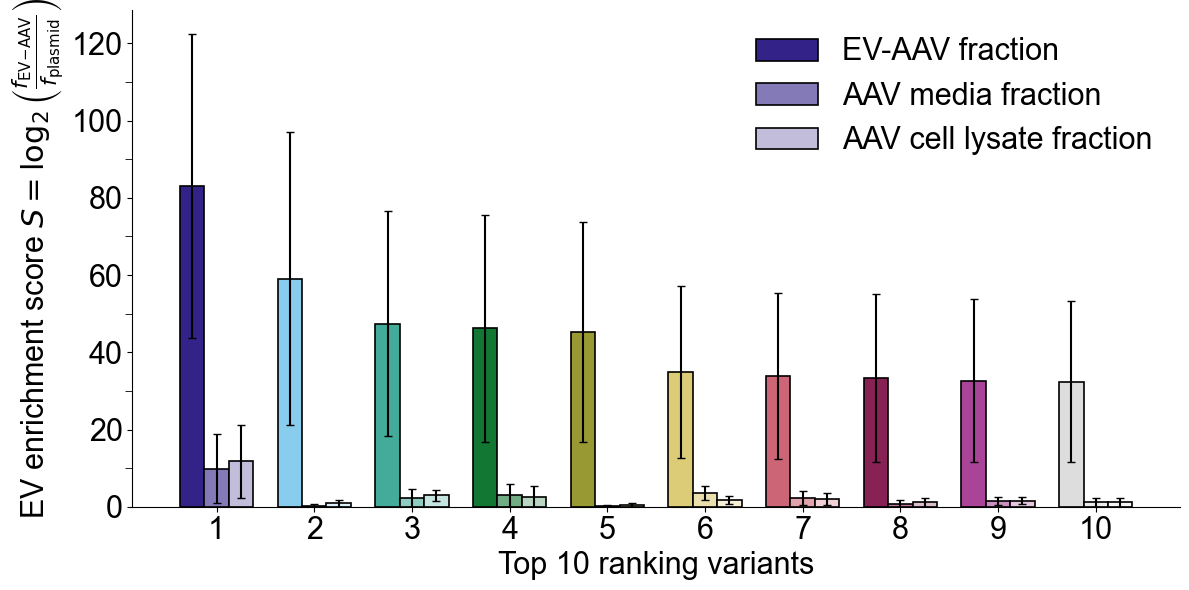

In [ ]:
## ML-Assisted DE Approach - Barplot with Arithmetic Mean and Standard Error

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib import rcParams
from matplotlib import colors as mcolors

# ───────────────────── USER SETTINGS ─────────────────────
xlsx_path = (
    "data/Excel/ml_assessment_library/EVAAV/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)
xlsx_path_AAV = (
    "data/Excel/ml_assessment_library/AAV_media/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)
xlsx_path_CL = (
    "data/Excel/ml_assessment_library/AAV_cell_lysate/"
    "merged_enrichment_scores_with_aa_column.xlsx"
)

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

# Paul Tol "Notes" palette (Fig. 4): indigo, cyan, teal, green, olive, sand, rose, wine, purple, pale grey
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)
df_AAV = pd.read_excel(xlsx_path_AAV)
df_CL = pd.read_excel(xlsx_path_CL)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()
avg_scores_AAV = df_AAV.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()
avg_scores_CL = df_CL.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()

# create replicate-specific dataframes including sequence
# and compute ranks based on score only

df_rep1 = avg_scores[['amino_acid_sequence','enrichment_score_rep_1']].copy()
df_rep2 = avg_scores[['amino_acid_sequence','enrichment_score_rep_2']].copy()
df_rep3 = avg_scores[['amino_acid_sequence','enrichment_score_rep_3']].copy()

df_rep1['rank'] = df_rep1['enrichment_score_rep_1'].rank(method='first')
df_rep1.sort_values('rank', ascending=False, inplace=True)
df_rep2['rank'] = df_rep2['enrichment_score_rep_2'].rank(method='first')
df_rep2.sort_values('rank', ascending=False, inplace=True)
df_rep3['rank'] = df_rep3['enrichment_score_rep_3'].rank(method='first')
df_rep3.sort_values('rank', ascending=False, inplace=True)

# merge and keep sequences for each replicate with explicit column names

df_combined = (
    df_rep1.rename(columns={'amino_acid_sequence':'sequence_rep_1'})
    .merge(df_rep2.rename(columns={'amino_acid_sequence':'sequence_rep_2'}), on='rank', how='inner')
    .merge(df_rep3.rename(columns={'amino_acid_sequence':'sequence_rep_3'}), on='rank', how='inner')
)

# Calculate arithmetic mean and standard error across replicates
df_combined["arithmetic_mean_enrichment"] = df_combined[rep_cols].mean(axis=1)
df_combined["std_error"] = df_combined[rep_cols].sem(axis=1)
print(df_combined.head())
# Retrieve top ranked variants for statistical testing
top_ml_scores = np.array([
    df_combined.iloc[0]["enrichment_score_rep_1"],
    df_combined.iloc[0]["enrichment_score_rep_2"],
    df_combined.iloc[0]["enrichment_score_rep_3"]
])

top10_df = df_combined.head(10).reset_index(drop=True)

# look up enrichment for each sequence column in AAV/CL and add to top10_df

def lookup_mean(seq, avg_df):
    row = avg_df[avg_df['amino_acid_sequence'] == seq]
    if row.empty:
        return np.nan
    return row[rep_cols].mean(axis=1).iloc[0]

for i in range(1, 4):
    seq_col = f"sequence_rep_{i}"
    top10_df[f"aav_mean_{i}"] = top10_df[seq_col].apply(lambda s: lookup_mean(s, avg_scores_AAV))
    top10_df[f"cl_mean_{i}"] = top10_df[seq_col].apply(lambda s: lookup_mean(s, avg_scores_CL))

# replace NaNs with zero in individual means before computing row means
top10_df[[f'aav_mean_{i}' for i in range(1,4)]] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].fillna(0)
top10_df[[f'cl_mean_{i}' for i in range(1,4)]] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].fillna(0)

# compute row-wise arithmetic mean enrichment for AAV and CL
top10_df['aav_mean_all'] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].mean(axis=1)
top10_df['cl_mean_all'] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].mean(axis=1)

# compute standard error across the three replicate means for AAV and CL
top10_df['aav_se_all'] = top10_df[[f'aav_mean_{i}' for i in range(1,4)]].sem(axis=1)
top10_df['cl_se_all'] = top10_df[[f'cl_mean_{i}' for i in range(1,4)]].sem(axis=1)

# ─────────────── STYLE CONSTANTS ───────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# ───────────────────── PLOT ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10_df))
width = 0.25  # width of each bar

# mix with white: fractions for media and lysate
def lighten(col, frac):
    return tuple(col[i] + (1-col[i])*frac for i in range(3))

for xi in x:
    col_ev = mcolors.to_rgb(tol_notes[xi])
    col_media = lighten(col_ev, 0.4)
    col_lysate = lighten(col_ev, 0.7)
    ax.bar(xi - width, top10_df.loc[xi, "arithmetic_mean_enrichment"], width,
            color=col_ev, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "std_error"], capsize=3)
    ax.bar(xi, top10_df.loc[xi, "aav_mean_all"], width,
            color=col_media, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "aav_se_all"], capsize=3)
    ax.bar(xi + width, top10_df.loc[xi, "cl_mean_all"], width,
            color=col_lysate, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "cl_se_all"], capsize=3)

# (scatter points removed)

ax.set_xlabel("Top 10 ranking variants", fontsize=base_fs)
ax.set_ylabel(r"EV enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=base_fs)
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x])
legend = ax.legend(["EV-AAV fraction","AAV media fraction","AAV cell lysate fraction"], frameon=False)

# add minor ticks at specified y-values
minor_ticks = [10, 30, 50, 70, 90, 110]
ax.set_yticks(minor_ticks, minor=True)
ax.tick_params(axis='y', which='minor', length=5)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

[5.14709745 5.61262859 5.76210547]


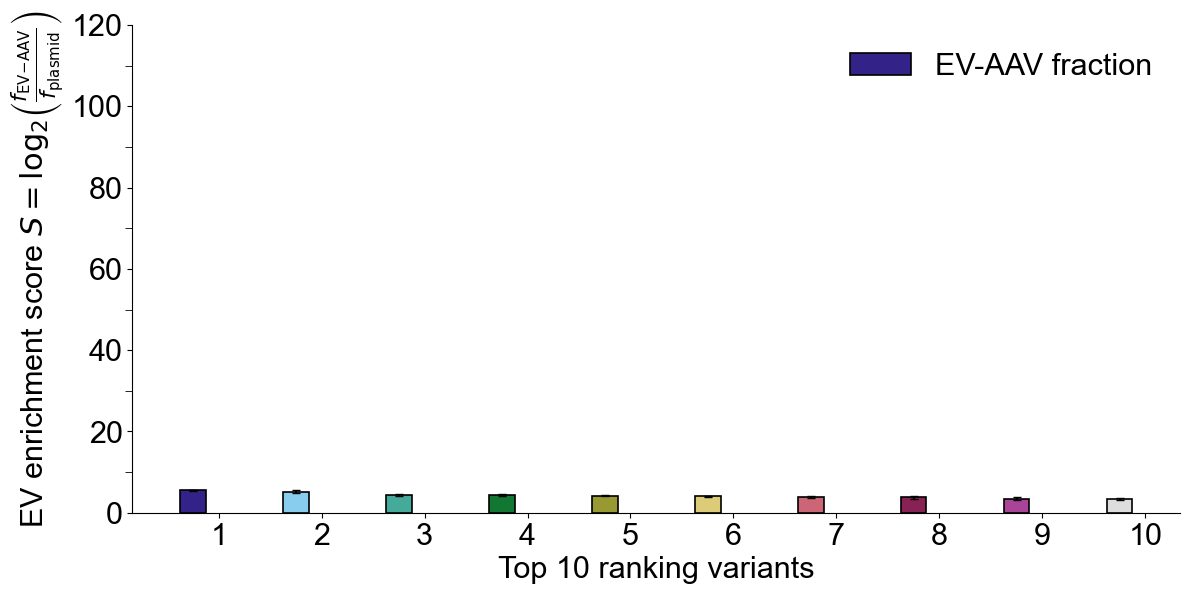

In [ ]:
## ML-Assisted DE Approach - Barplot with Arithmetic Mean and Standard Error

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib import rcParams
from matplotlib import colors as mcolors

# ───────────────────── USER SETTINGS ─────────────────────
xlsx_path = (
    "data/Excel/directed_evolution_assessment_library/merged_enrichment_scores_with_aa_column.xlsx"
)

rep_cols = [
    "enrichment_score_rep_1",
    "enrichment_score_rep_2",
    "enrichment_score_rep_3",
]

# Paul Tol "Notes" palette
tol_notes = [
    "#332288", "#88CCEE", "#44AA99", "#117733", "#999933",
    "#DDCC77", "#CC6677", "#882255", "#AA4499", "#DDDDDD"
]

# ───────────── LOAD & PREP DATA ─────────────
df = pd.read_excel(xlsx_path)

# Group by amino acid sequence and calculate mean for each replicate
avg_scores = df.groupby('amino_acid_sequence')[rep_cols].mean().reset_index()

# create replicate-specific dataframes including sequence
# and compute ranks based on score only

df_rep1 = avg_scores[['amino_acid_sequence','enrichment_score_rep_1']].copy()
df_rep2 = avg_scores[['amino_acid_sequence','enrichment_score_rep_2']].copy()
df_rep3 = avg_scores[['amino_acid_sequence','enrichment_score_rep_3']].copy()

df_rep1['rank'] = df_rep1['enrichment_score_rep_1'].rank(method='first')
df_rep1.sort_values('rank', ascending=False, inplace=True)
df_rep2['rank'] = df_rep2['enrichment_score_rep_2'].rank(method='first')
df_rep2.sort_values('rank', ascending=False, inplace=True)
df_rep3['rank'] = df_rep3['enrichment_score_rep_3'].rank(method='first')
df_rep3.sort_values('rank', ascending=False, inplace=True)

# merge and keep sequences for each replicate with explicit column names

df_combined = (
    df_rep1.rename(columns={'amino_acid_sequence':'sequence_rep_1'})
    .merge(df_rep2.rename(columns={'amino_acid_sequence':'sequence_rep_2'}), on='rank', how='inner')
    .merge(df_rep3.rename(columns={'amino_acid_sequence':'sequence_rep_3'}), on='rank', how='inner')
)

# Calculate arithmetic mean and standard error across replicates
df_combined["arithmetic_mean_enrichment"] = df_combined[rep_cols].mean(axis=1)
df_combined["std_error"] = df_combined[rep_cols].sem(axis=1)

# Retrieve top ranked variants for statistical testing
top_de_scores = np.array([
    df_combined.iloc[0]["enrichment_score_rep_1"],
    df_combined.iloc[0]["enrichment_score_rep_2"],
    df_combined.iloc[0]["enrichment_score_rep_3"]
])

print(top_de_scores)

top10_df = df_combined.head(10).reset_index(drop=True)
ml_scores = np.asarray(top10_df["arithmetic_mean_enrichment"])

# ─────────────── STYLE CONSTANTS ───────────────
base_fs = 22
rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.titlesize": base_fs,
    "axes.labelsize": base_fs,
    "xtick.labelsize": base_fs,
    "ytick.labelsize": base_fs,
    "legend.fontsize": base_fs,
})

# ───────────────────── PLOT ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top10_df))
width = 0.25  # width of each bar

# mix with white: fractions for media and lysate
def lighten(col, frac):
    return tuple(col[i] + (1-col[i])*frac for i in range(3))

for xi in x:
    col_ev = mcolors.to_rgb(tol_notes[xi])
    ax.bar(xi - width, top10_df.loc[xi, "arithmetic_mean_enrichment"], width,
            color=col_ev, edgecolor="black", linewidth=1.2,
            yerr=top10_df.loc[xi, "std_error"], capsize=3)

# (scatter points removed)
ax.set_xlabel("Top 10 ranking variants", fontsize=base_fs)
ax.set_ylabel(r"EV enrichment score $S = \log_2\left(\frac{f_{\mathrm{EV\!-\!AAV}}}{f_{\mathrm{plasmid}}}\right)$", fontsize=base_fs)
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x])
legend = ax.legend(["EV-AAV fraction"],frameon=False)

# add minor ticks at specified y-values
minor_ticks = [10, 30, 50, 70, 90, 110]
ax.set_yticks(minor_ticks, minor=True)
ax.tick_params(axis='y', which='minor', length=5)
ax.set_ylim(0, 120)

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

# One-sided Mann–Whitney U test
u_statistic, p_value = mannwhitneyu(
    top_ml_scores,
    top_de_scores,
    alternative='greater'
)

# Print results
print("Mann–Whitney U statistic:", u_statistic)
print("p-value:", p_value)

# Significance threshold
alpha = 0.05

# Interpret result
if p_value <= alpha:
    print("The difference between groups is statistically significant.")
else:
    print("No statistically significant difference was detected.")

[ 17.94985058 154.15280998  77.18795355]
[5.14709745 5.61262859 5.76210547]
Mann–Whitney U statistic: 9.0
p-value: 0.05
The difference between groups is statistically significant.
